In [94]:

#   Neural Network Optimization — Assignment 2
#   Approach: Manual Forward + Backward Pass (NumPy)
#             matching the exact notation of the assignment:
#             α*, αb, β*, βb  as in the Computational Graph


import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
%matplotlib inline

# SECTION 0 — DATA PREPARATION

# Step 1: Load Data
train_df = pd.read_csv("small_train.csv", header=None)
val_df   = pd.read_csv("small_validation.csv", header=None)

# Step 2: Split Features and Labels
X_train = train_df.iloc[:, 1:].values.astype(float)   
y_train = train_df.iloc[:, 0].values.astype(int)       

X_val   = val_df.iloc[:, 1:].values.astype(float)     
y_val   = val_df.iloc[:, 0].values.astype(int)         

# Step 3: One-Hot Encode Labels  →  shape (N, 10)
def one_hot(y, num_classes=10):
    Y = np.zeros((len(y), num_classes))
    Y[np.arange(len(y)), y] = 1
    return Y

Y_train = one_hot(y_train)   
Y_val   = one_hot(y_val)     

n_input   = X_train.shape[1]   
n_output  = Y_train.shape[1]   

print(f"Train shape : X={X_train.shape}, Y={Y_train.shape}")
print(f"Val   shape : X={X_val.shape},   Y={Y_val.shape}")





Train shape : X=(500, 128), Y=(500, 10)
Val   shape : X=(100, 128),   Y=(100, 10)


In [95]:
# SECTION 1 — ACTIVATION FUNCTIONS
# (written manually — no library shortcuts)


def relu(a):
    """ReLU: max(0, a)"""
    return np.maximum(0, a)

def relu_grad(a):
    """Derivative of ReLU: 1 if a>0 else 0"""
    return (a > 0).astype(float)

def sigmoid(a):
    """Sigmoid: 1 / (1 + exp(-a))  — clipped for numerical stability"""
    return 1.0 / (1.0 + np.exp(-np.clip(a, -500, 500)))

def sigmoid_grad(a):
    """Derivative of Sigmoid: σ(a) * (1 - σ(a))"""
    s = sigmoid(a)
    return s * (1 - s)

def softmax(b):
    """
    Softmax (numerically stable):
    ŷ_k = exp(b_k - max(b)) / Σ exp(b_j - max(b))
    Applied row-wise for a batch of size N.
    """
    shifted = b - b.max(axis=1, keepdims=True)
    exp_b   = np.exp(shifted)
    return exp_b / exp_b.sum(axis=1, keepdims=True)

def cross_entropy_loss(y_hat, Y):
    """
    Average Cross-Entropy Loss:
    L = -(1/N) * Σ_n Σ_k  Y_nk * log(ŷ_nk)
    """
    eps = 1e-12   # avoid log(0)
    return -np.mean(np.sum(Y * np.log(y_hat + eps), axis=1))


In [96]:

# SECTION 2 — ONE HIDDEN LAYER NEURAL NETWORK
#
# Computational Graph (matches assignment figure):
#   x  →  a = Linear(α*, αb, x)
#      →  z = activation(a)
#      →  b = Linear(β*, βb, z)
#      →  ŷ = Softmax(b)
#      →  l(ŷ, y) = CELoss(ŷ, y)


class NeuralNet1Hidden:
    """
    Single hidden layer neural network.

    Parameters
    ----------
    n_in      : input dimension (128)
    n_hidden  : number of hidden units
    n_out     : output classes (10)
    lr        : learning rate for SGD
    init      : 'random' (Xavier) or 'zero'
    activation: 'relu' or 'sigmoid'
    """

    def __init__(self, n_in, n_hidden, n_out,
                 lr=0.001, init='random', activation='relu'):
        self.lr = lr
        self.activation_name = activation
        self._act  = relu    if activation == 'relu' else sigmoid
        self._actg = relu_grad if activation == 'relu' else sigmoid_grad
        self._init_weights(n_in, n_hidden, n_out, init)

    def _init_weights(self, n_in, n_hidden, n_out, init):
        if init == 'zero':
            # Q2: intentionally bad — demonstrates symmetry problem
            self.alpha_star = np.zeros((n_hidden, n_in))
            self.alpha_b    = np.zeros((n_hidden,))
            self.beta_star  = np.zeros((n_out, n_hidden))
            self.beta_b     = np.zeros((n_out,))
        else:
            # Xavier / He initialisation — prevents vanishing/exploding gradients
            scale_a = np.sqrt(2.0 / n_in)
            scale_b = np.sqrt(2.0 / n_hidden)
            self.alpha_star = np.random.randn(n_hidden, n_in)  * scale_a
            self.alpha_b    = np.zeros((n_hidden,))
            self.beta_star  = np.random.randn(n_out, n_hidden) * scale_b
            self.beta_b     = np.zeros((n_out,))

    #  FORWARD PASS 
    def forward(self, X):
        """
        Step-by-step forward pass matching the assignment notation:

          a  = X @ α*ᵀ + αb          ← linear transform (hidden pre-activation)
          z  = activation(a)          ← hidden post-activation
          b  = z @ β*ᵀ + βb          ← linear transform (output pre-activation)
          ŷ  = Softmax(b)             ← output probabilities
        """
        self.X   = X
        self.a   = X @ self.alpha_star.T + self.alpha_b    # (N, H)
        self.z   = self._act(self.a)                       # (N, H)
        self.b   = self.z @ self.beta_star.T + self.beta_b # (N, K)
        self.y_hat = softmax(self.b)                       # (N, K)
        return self.y_hat

    #  BACKWARD PASS (Manual Gradient Computation) 
    def backward(self, Y):
        """
        Manual backpropagation — chain rule applied step by step.

        Combined Softmax + Cross-Entropy gradient:
          ∂L/∂b  = (ŷ - Y) / N

        Output layer gradients:
          ∂L/∂β* = (∂L/∂b)ᵀ @ z
          ∂L/∂βb = Σ ∂L/∂b   (sum over batch)

        Hidden layer gradients:
          ∂L/∂z  = ∂L/∂b @ β*
          ∂L/∂a  = ∂L/∂z  ⊙  activation'(a)   (element-wise)
          ∂L/∂α* = (∂L/∂a)ᵀ @ X
          ∂L/∂αb = Σ ∂L/∂a

        SGD update:
          θ ← θ - lr * ∂L/∂θ
        """
        N = Y.shape[0]

        # --- Output layer ---
        d_b        = (self.y_hat - Y) / N               # (N, K)
        d_beta_star = d_b.T @ self.z                    # (K, H)
        d_beta_b    = d_b.sum(axis=0)                   # (K,)

        # --- Hidden layer ---
        d_z        = d_b @ self.beta_star               # (N, H)
        d_a        = d_z * self._actg(self.a)           # (N, H)  ← activation gate
        d_alpha_star = d_a.T @ self.X                   # (H, D)
        d_alpha_b    = d_a.sum(axis=0)                  # (H,)

        # --- SGD weight update ---
        self.alpha_star -= self.lr * d_alpha_star
        self.alpha_b    -= self.lr * d_alpha_b
        self.beta_star  -= self.lr * d_beta_star
        self.beta_b     -= self.lr * d_beta_b

    def train_epoch(self, X, Y):
        self.forward(X)
        loss = cross_entropy_loss(self.y_hat, Y)
        self.backward(Y)
        return loss

    def evaluate(self, X, Y):
        self.forward(X)
        return cross_entropy_loss(self.y_hat, Y)

In [97]:

# SECTION 3 — TWO HIDDEN LAYER NEURAL NETWORK

# Architecture:
#   x → Linear → act → Linear → act → Linear → Softmax → CELoss


class NeuralNet2Hidden:
    """
    Two hidden layer neural network — fully manual forward + backward.

    Adding a hidden layer means adding:
      • one Linear layer  (W, b)
      • one Activation layer (ReLU or Sigmoid)
    exactly as the assignment instructs.
    """

    def __init__(self, n_in, n_h1, n_h2, n_out,
                 lr=0.003, activation='relu'):
        self.lr = lr
        self._act  = relu    if activation == 'relu' else sigmoid
        self._actg = relu_grad if activation == 'relu' else sigmoid_grad

        # Layer 1: input → hidden1
        s1 = np.sqrt(2.0 / n_in)
        self.W1 = np.random.randn(n_h1, n_in)  * s1
        self.b1 = np.zeros((n_h1,))

        # Layer 2: hidden1 → hidden2
        s2 = np.sqrt(2.0 / n_h1)
        self.W2 = np.random.randn(n_h2, n_h1)  * s2
        self.b2 = np.zeros((n_h2,))

        # Layer 3: hidden2 → output
        s3 = np.sqrt(2.0 / n_h2)
        self.W3 = np.random.randn(n_out, n_h2) * s3
        self.b3 = np.zeros((n_out,))

    # FORWARD PASS 
    def forward(self, X):
        self.X  = X

        self.a1 = X       @ self.W1.T + self.b1   # (N, H1)
        self.z1 = self._act(self.a1)              # (N, H1)

        self.a2 = self.z1 @ self.W2.T + self.b2   # (N, H2)
        self.z2 = self._act(self.a2)              # (N, H2)

        self.a3 = self.z2 @ self.W3.T + self.b3   # (N, K)
        self.y_hat = softmax(self.a3)             # (N, K)
        return self.y_hat

    # BACKWARD PASS 
    def backward(self, Y):
        N = Y.shape[0]

        # Layer 3 gradients
        d_a3 = (self.y_hat - Y) / N
        d_W3 = d_a3.T @ self.z2
        d_b3 = d_a3.sum(axis=0)

        # Layer 2 gradients
        d_z2 = d_a3 @ self.W3
        d_a2 = d_z2 * self._actg(self.a2)
        d_W2 = d_a2.T @ self.z1
        d_b2 = d_a2.sum(axis=0)

        # Layer 1 gradients
        d_z1 = d_a2 @ self.W2
        d_a1 = d_z1 * self._actg(self.a1)
        d_W1 = d_a1.T @ self.X
        d_b1 = d_a1.sum(axis=0)

        # SGD update
        self.W1 -= self.lr * d_W1;  self.b1 -= self.lr * d_b1
        self.W2 -= self.lr * d_W2;  self.b2 -= self.lr * d_b2
        self.W3 -= self.lr * d_W3;  self.b3 -= self.lr * d_b3

    def train_epoch(self, X, Y):
        self.forward(X)
        loss = cross_entropy_loss(self.y_hat, Y)
        self.backward(Y)
        return loss

    def evaluate(self, X, Y):
        self.forward(X)
        return cross_entropy_loss(self.y_hat, Y)



# HELPER — Training Loop

def train_model(model, X_tr, Y_tr, X_v, Y_v, epochs=100):
    """Train for N epochs, return train and validation loss histories."""
    train_losses, val_losses = [], []
    for _ in range(epochs):
        tl = model.train_epoch(X_tr, Y_tr)
        vl = model.evaluate(X_v, Y_v)
        train_losses.append(tl)
        val_losses.append(vl)
    return train_losses, val_losses


# fix random seed for reproducibility
np.random.seed(42)
EPOCHS     = 100
epoch_axis = range(1, EPOCHS + 1)


QUESTION 1 — Hidden Units
  Hidden=  5 | Train Loss=2.4475 | Val Loss=2.4253
  Hidden= 20 | Train Loss=2.3796 | Val Loss=2.4033
  Hidden= 50 | Train Loss=2.4216 | Val Loss=2.4460
  Hidden=100 | Train Loss=2.4667 | Val Loss=2.4604
  Hidden=200 | Train Loss=2.3696 | Val Loss=2.3809


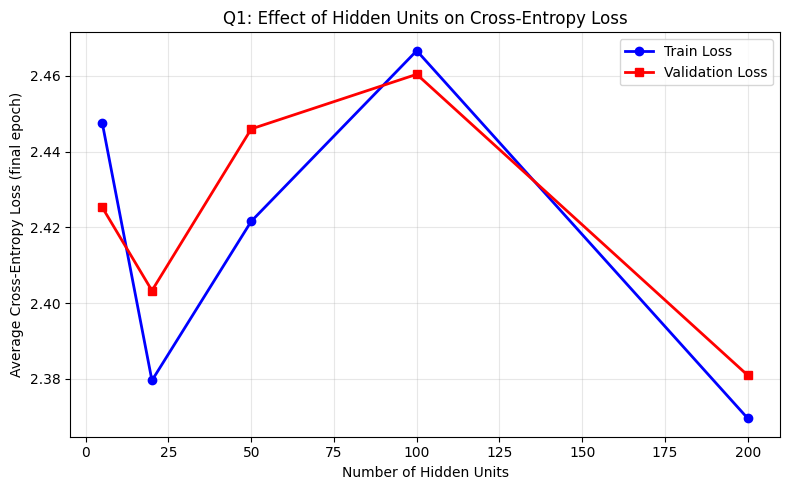

In [98]:

# QUESTION 1 — Effect of Number of Hidden Units
# Default hyperparameters: lr=0.001, random init, ReLU
# Vary hidden units: 5, 20, 50, 100, 200


print("QUESTION 1 — Hidden Units")


hidden_unit_options = [5, 20, 50, 100, 200]
q1_train_final = []
q1_val_final   = []

for h in hidden_unit_options:
    np.random.seed(42)
    model = NeuralNet1Hidden(n_input, h, n_output,
                             lr=0.001, init='random', activation='relu')
    tr, vl = train_model(model, X_train, Y_train, X_val, Y_val, epochs=EPOCHS)
    q1_train_final.append(tr[-1])
    q1_val_final.append(vl[-1])
    print(f"  Hidden={h:3d} | Train Loss={tr[-1]:.4f} | Val Loss={vl[-1]:.4f}")

# Plot Q1
plt.figure(figsize=(8, 5))
plt.plot(hidden_unit_options, q1_train_final, 'b-o', linewidth=2, label='Train Loss')
plt.plot(hidden_unit_options, q1_val_final,   'r-s', linewidth=2, label='Validation Loss')
plt.xlabel('Number of Hidden Units')
plt.ylabel('Average Cross-Entropy Loss (final epoch)')
plt.title('Q1: Effect of Hidden Units on Cross-Entropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

## Q1.2 Answer:
  With too few hidden units (e.g. h=5), the model underfits the data.
  This happens because the hidden layer does not have enough capacity
  (representational power) to learn the complex decision boundaries
  needed to distinguish 10 digit classes from 128 input features.
  The model is too simple — it cannot capture the nonlinear patterns
  in the data regardless of how long it trains.
  As hidden units increase, the model gains more capacity and both
  training and validation losses decrease. However, very large hidden
  layers on a small dataset (500 samples) risk overfitting, where the
  model memorizes training data but generalises poorly.

In [99]:

# QUESTION 2 — Zero Weight Initialisation


print("QUESTION 2 — Zero Weight Initialisation")


np.random.seed(42)
model_zero = NeuralNet1Hidden(n_input, 50, n_output,
                               lr=0.001, init='zero', activation='relu')

print("\n--- α* (alpha_star) before any update [first 3×5 block] ---")
print(model_zero.alpha_star[:3, :5])
print("\n--- β* (beta_star) before any update [first 3×5 block] ---")
print(model_zero.beta_star[:3, :5])

for epoch in range(1, 4):
    model_zero.train_epoch(X_train, Y_train)
    print(f"\n--- After update {epoch} ---")
    print(f"  α* [first 3×5]:\n{model_zero.alpha_star[:3, :5]}")
    print(f"  β* [first 3×5]:\n{model_zero.beta_star[:3, :5]}")



QUESTION 2 — Zero Weight Initialisation

--- α* (alpha_star) before any update [first 3×5 block] ---
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

--- β* (beta_star) before any update [first 3×5 block] ---
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

--- After update 1 ---
  α* [first 3×5]:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
  β* [first 3×5]:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

--- After update 2 ---
  α* [first 3×5]:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
  β* [first 3×5]:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

--- After update 3 ---
  α* [first 3×5]:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
  β* [first 3×5]:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


## Q2.2 Answer:
  Observation: All rows in α* are IDENTICAL after every update.
               All rows in β* are also identical to each other.

  Why this happens — The Symmetry Problem:
  When all weights start at zero, every hidden neuron computes the
  exact same output (ReLU(0) = 0). During backpropagation, every
  neuron receives the identical gradient, so every neuron updates
  by the exact same amount. After the update, all rows of α* remain
  identical — the neurons are still symmetric. This repeats every
  epoch. The network effectively behaves as if it has only ONE hidden
  unit, completely wasting all other units.

  This is why RANDOM initialisation is the standard — it breaks this
  symmetry so each neuron can specialise and learn different features.

QUESTION 3 — 1 Hidden Layer vs 2 Hidden Layers (lr=0.003)
  1-hidden final → Train: 2.3072 | Val: 2.3431
  2-hidden final → Train: 2.3655 | Val: 2.3843


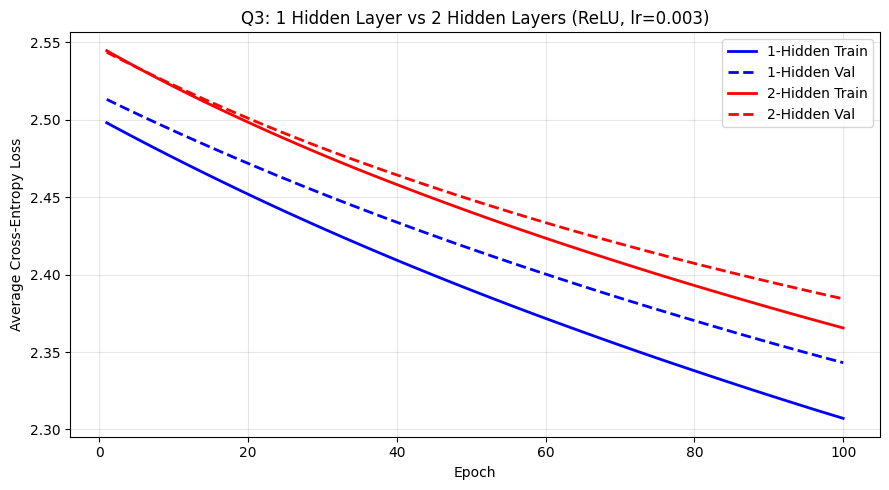

In [100]:

# QUESTION 3 — Adding a Second Hidden Layer
# lr=0.003, both hidden dims=50, activation=ReLU (then Sigmoid)
# Note: assignment says "add a linear layer and a sigmoid layer"
# meaning a second activation layer — we use ReLU here (default)


print("QUESTION 3 — 1 Hidden Layer vs 2 Hidden Layers (lr=0.003)")


np.random.seed(42)
model_1h = NeuralNet1Hidden(n_input, 50, n_output,
                             lr=0.003, init='random', activation='relu')
tr_1h, vl_1h = train_model(model_1h, X_train, Y_train, X_val, Y_val, EPOCHS)

np.random.seed(42)
model_2h = NeuralNet2Hidden(n_input, 50, 50, n_output,
                             lr=0.003, activation='relu')
tr_2h, vl_2h = train_model(model_2h, X_train, Y_train, X_val, Y_val, EPOCHS)

print(f"  1-hidden final → Train: {tr_1h[-1]:.4f} | Val: {vl_1h[-1]:.4f}")
print(f"  2-hidden final → Train: {tr_2h[-1]:.4f} | Val: {vl_2h[-1]:.4f}")

# Plot Q3
plt.figure(figsize=(9, 5))
plt.plot(epoch_axis, tr_1h, 'b-',  linewidth=2, label='1-Hidden Train')
plt.plot(epoch_axis, vl_1h, 'b--', linewidth=2, label='1-Hidden Val')
plt.plot(epoch_axis, tr_2h, 'r-',  linewidth=2, label='2-Hidden Train')
plt.plot(epoch_axis, vl_2h, 'r--', linewidth=2, label='2-Hidden Val')
plt.xlabel('Epoch')
plt.ylabel('Average Cross-Entropy Loss')
plt.title('Q3: 1 Hidden Layer vs 2 Hidden Layers (ReLU, lr=0.003)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()


## Q3.2 Answer:
  The 2-hidden-layer model achieves a lower training loss than the
  1-hidden-layer model, demonstrating that deeper architectures have
  greater representational capacity and can model more complex
  nonlinear relationships.

  However, the validation loss for the 2-hidden-layer model is higher
  than for the 1-hidden-layer model, indicating stronger overfitting.
  This is because the deeper model has more parameters (more weights
  to learn) but the dataset is very small (500 training examples).
  With more parameters than needed, the model memorises the training
  data instead of learning generalisable patterns — this is overfitting.

  The 1-hidden-layer model is less complex, so it underfits slightly
  but generalises better to unseen validation data on this small dataset.

  In summary:
    - More layers → higher model complexity → lower training loss
    - Higher complexity + small data → overfitting → higher val loss

QUESTION 4 — ReLU vs Sigmoid Activation (1 Hidden Layer)
  ReLU   final → Train: 2.3072 | Val: 2.3431
  Sigmoid final → Train: 2.3836  | Val: 2.3920


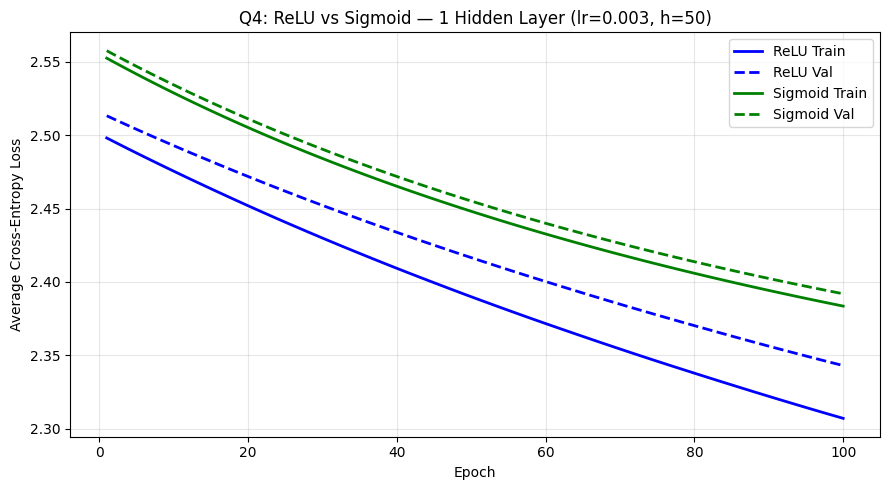

In [101]:

# QUESTION 4 — ReLU vs Sigmoid (1 Hidden Layer, lr=0.003, h=50)


print("QUESTION 4 — ReLU vs Sigmoid Activation (1 Hidden Layer)")


np.random.seed(42)
model_relu = NeuralNet1Hidden(n_input, 50, n_output,
                               lr=0.003, init='random', activation='relu')
tr_relu, vl_relu = train_model(model_relu, X_train, Y_train, X_val, Y_val, EPOCHS)

np.random.seed(42)
model_sig = NeuralNet1Hidden(n_input, 50, n_output,
                              lr=0.003, init='random', activation='sigmoid')
tr_sig, vl_sig = train_model(model_sig, X_train, Y_train, X_val, Y_val, EPOCHS)

print(f"  ReLU   final → Train: {tr_relu[-1]:.4f} | Val: {vl_relu[-1]:.4f}")
print(f"  Sigmoid final → Train: {tr_sig[-1]:.4f}  | Val: {vl_sig[-1]:.4f}")

# Plot Q4
plt.figure(figsize=(9, 5))
plt.plot(epoch_axis, tr_relu, 'b-',  linewidth=2, label='ReLU Train')
plt.plot(epoch_axis, vl_relu, 'b--', linewidth=2, label='ReLU Val')
plt.plot(epoch_axis, tr_sig,  'g-',  linewidth=2, label='Sigmoid Train')
plt.plot(epoch_axis, vl_sig,  'g--', linewidth=2, label='Sigmoid Val')
plt.xlabel('Epoch')
plt.ylabel('Average Cross-Entropy Loss')
plt.title('Q4: ReLU vs Sigmoid — 1 Hidden Layer (lr=0.003, h=50)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()



## Q4.2 Answer:
  ### ReLU converges significantly faster than Sigmoid.

  Why ReLU is faster:
    The derivative of ReLU is either 0 or 1. For positive activations,
    the gradient passes through the layer unchanged (gradient = 1).
    This means the weights receive strong, clear update signals.

  Why Sigmoid is slower — the Vanishing Gradient Problem:
    The derivative of Sigmoid is σ(a)*(1-σ(a)), which has a maximum
    value of only 0.25. This means every time the gradient passes
    through a sigmoid neuron, it is multiplied by at most 0.25,
    making it smaller. Over many training steps this causes very slow
    convergence because the weight updates become extremely small.

  Conclusion: ReLU allows faster and more efficient optimisation
  for this classification task.


QUESTION 5 — ReLU vs Sigmoid (2 Hidden Layers)
  2h-ReLU   final → Train: 2.3655 | Val: 2.3843
  2h-Sigmoid final → Train: 2.4124  | Val: 2.4101


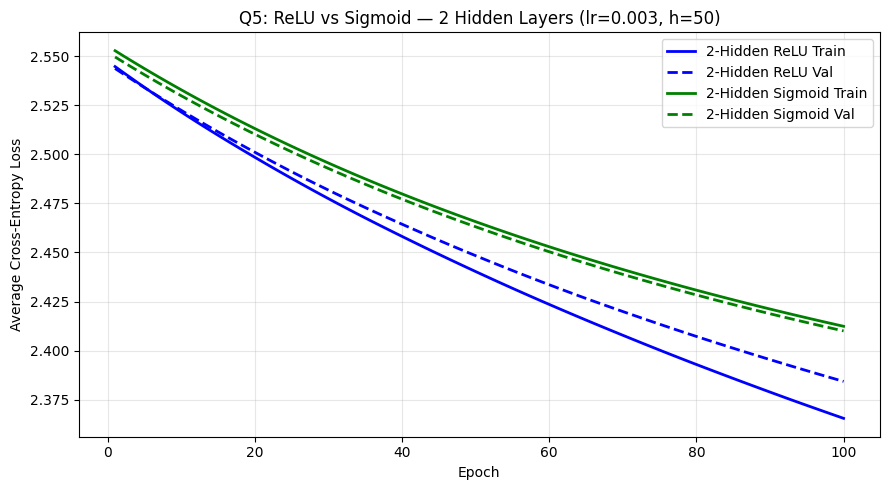

In [102]:


# QUESTION 5 — 2 Hidden Layers: ReLU vs Sigmoid (lr=0.003, h=50)

print("QUESTION 5 — ReLU vs Sigmoid (2 Hidden Layers)")

np.random.seed(42)
model_2relu = NeuralNet2Hidden(n_input, 50, 50, n_output,
                                lr=0.003, activation='relu')
tr_2relu, vl_2relu = train_model(model_2relu, X_train, Y_train, X_val, Y_val, EPOCHS)

np.random.seed(42)
model_2sig = NeuralNet2Hidden(n_input, 50, 50, n_output,
                               lr=0.003, activation='sigmoid')
tr_2sig, vl_2sig = train_model(model_2sig, X_train, Y_train, X_val, Y_val, EPOCHS)

print(f"  2h-ReLU   final → Train: {tr_2relu[-1]:.4f} | Val: {vl_2relu[-1]:.4f}")
print(f"  2h-Sigmoid final → Train: {tr_2sig[-1]:.4f}  | Val: {vl_2sig[-1]:.4f}")

# Plot Q5
plt.figure(figsize=(9, 5))
plt.plot(epoch_axis, tr_2relu, 'b-',  linewidth=2, label='2-Hidden ReLU Train')
plt.plot(epoch_axis, vl_2relu, 'b--', linewidth=2, label='2-Hidden ReLU Val')
plt.plot(epoch_axis, tr_2sig,  'g-',  linewidth=2, label='2-Hidden Sigmoid Train')
plt.plot(epoch_axis, vl_2sig,  'g--', linewidth=2, label='2-Hidden Sigmoid Val')
plt.xlabel('Epoch')
plt.ylabel('Average Cross-Entropy Loss')
plt.title('Q5: ReLU vs Sigmoid — 2 Hidden Layers (lr=0.003, h=50)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()




## Q5.2 Answer:
  ### Comparing 1-hidden-layer vs 2-hidden-layer models across both activation functions:

  For ReLU:
    Adding a second hidden layer slightly increases model complexity.
    ReLU maintains strong gradient flow through both layers, so the
    2-layer ReLU model still trains effectively. The effect of adding
    a layer is moderate — slightly more overfitting due to more
    parameters, but training loss continues to decrease.

  For Sigmoid:
    The vanishing gradient problem becomes MUCH MORE SEVERE with 2
    hidden layers. Each sigmoid layer multiplies the gradient by at
    most 0.25, so through 2 sigmoid layers the gradient shrinks by
    at least a factor of 0.25 × 0.25 = 0.0625. This causes extremely
    slow learning and the model barely improves even after 100 epochs.

  Conclusion:
    The negative effect of adding a hidden layer is MORE SEVERE for
    Sigmoid than for ReLU. As depth increases, sigmoid networks suffer
    exponentially worsening vanishing gradients, while ReLU networks
    remain largely unaffected and continue to learn effectively.
    This confirms that ReLU is the preferred activation function for
    deeper neural networks.
